In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.community_detection import CommunityDetection
from src.ansatze import Ansatz
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA
from src.lvqe import LayerVQE
from quantum_walk.community_detection_qw import detect_communities, modularity, top_k_degree_vertices, visualize_communities


Graph: 15 nodes, 52 edges


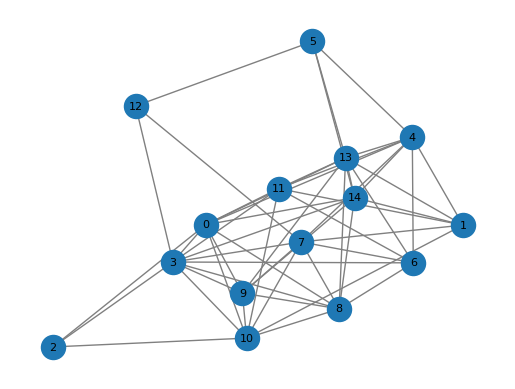

In [ ]:
G = nx.gnp_random_graph(n=15, p=0.5, seed=42)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos=pos, node_size=300, font_size=8, edge_color="gray")
plt.axis("off")
plt.show()

In [4]:
k = 4
problem = CommunityDetection(G, k)

sim = QuimbSimulator()
lvqe = LayerVQE(problem=problem, simulator=sim, optimizer_class=COBYLA, n_layers=2,
    k_per_layer=300, k_final=200, use_sampling=False)

result_lvqe = lvqe.run()

Starting L-VQE: 2 layers, 300 iter/layer, 200 final iter
Mode: exact expectation

Layer 0: 



COBYLA: 100%|██████████| 300/300 [02:42<00:00,  1.84it/s, best_E=-0.0981]


Total evaluations: 300
layer 0: energy=-0.0981, approx_ratio=+0.6503

Layer 1 — 300 iterations (before convergence)


COBYLA: 100%|██████████| 300/300 [03:20<00:00,  1.49it/s, best_E=-0.1246]


Total evaluations: 300
layer 1: energy=-0.1246, approx_ratio=+0.8260

Final layer — 200 iterations (final)


COBYLA: 264it [02:47,  1.58it/s, best_E=-0.1247]                         

Total evaluations: 264
layer 2: energy=-0.1247, approx_ratio=+0.8266


In [5]:
from itertools import product

def to_communities(assignment):
    groups = {}
    for node, label in enumerate(assignment):
        groups.setdefault(label, []).append(node)
    return groups

# L-VQE decoded
bitstrings = sim.get_most_frequent_assignments(
    result_lvqe['final_params'], result_lvqe['final_ansatz'], problem=problem
)

best_assignment, best_proba = bitstrings[0]
modularity_lvqe = problem.evaluate(best_assignment)
communities_lvqe = to_communities(best_assignment)
q_best = -problem.best_known_value  

print("LVQE decoded communities (most probable sample):")
for label, nodes in sorted(communities_lvqe.items()):
    print(f"  Community {label}: {nodes}")
print(f"LVQE decoded modularity Q = {modularity_lvqe:.4f} (probability: {best_proba:.3f}%)")
print(f"LVQE final energy (expectation) = {result_lvqe['final_energy']:.4f}")
print(f"Best-known modularity Q*        = {q_best:.4f}")
print(f"Approximation ratio (energy)    = {result_lvqe['final_approx_ratio']:.4f}")
print(f"Approximation ratio (decoded)   = {modularity_lvqe / q_best:.4f}")

LVQE decoded communities (most probable sample):
  Community 0: [0, 2, 3, 7, 8, 9, 10]
  Community 1: [1, 4, 6, 11, 13, 14]
  Community 2: [5, 12]
LVQE decoded modularity Q = 0.1337 (probability: 45.200%)
LVQE final energy (expectation) = -0.1247
Best-known modularity Q*        = 0.1509
Approximation ratio (energy)    = 0.8266
Approximation ratio (decoded)   = 0.8860


/tmp/ipykernel_9408/3696706647.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max(n_colors, 2))


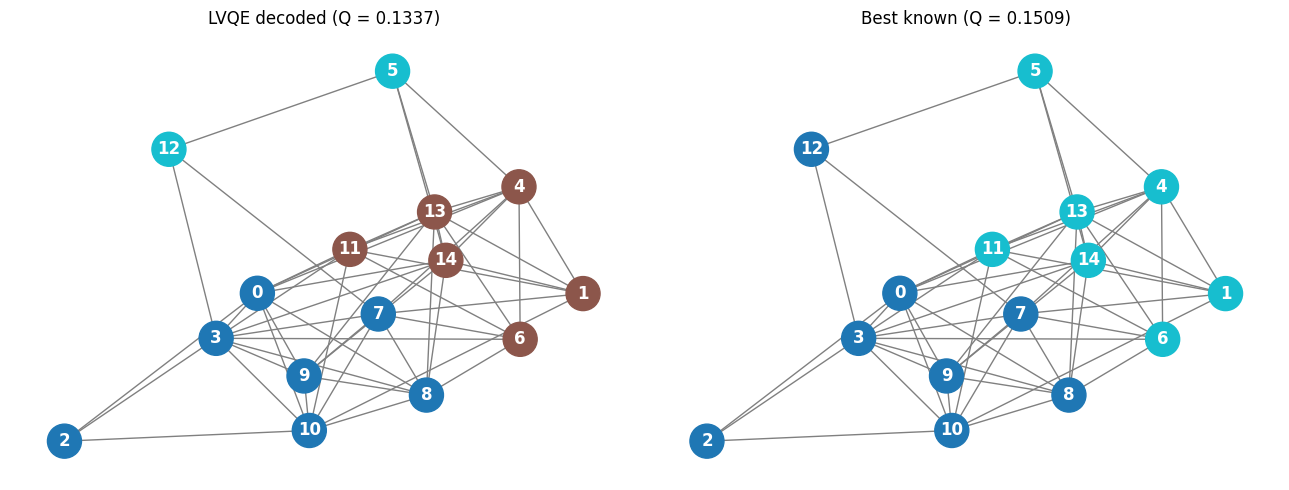

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from networkx.algorithms.community import louvain_communities

# recover the best-known assignment (Louvain, same as the class used for n>12)
best_assignment_exact = [0] * problem.num_nodes
for comm_idx, comm in enumerate(louvain_communities(G, seed=problem.seed)):
    for node in comm:
        best_assignment_exact[node] = comm_idx
best_q = problem.evaluate(best_assignment_exact)


def draw_partition(ax, assignment, title):
    pos = nx.spring_layout(G, seed=42)
    n_colors = max(assignment) + 1
    cmap = cm.get_cmap("tab10", max(n_colors, 2))
    node_colors = [cmap(assignment[node]) for node in G.nodes()]
    nx.draw_networkx(
        G, pos=pos, node_color=node_colors, with_labels=True,
        node_size=600, font_color="white", font_weight="bold",
        edge_color="gray", ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_partition(axes[0], best_assignment, f"LVQE decoded (Q = {modularity_lvqe:.4f})")
draw_partition(axes[1], best_assignment_exact, f"Best known (Q = {best_q:.4f})")
plt.tight_layout()
plt.show()

In [13]:
V_max = top_k_degree_vertices(G, k)
print(f"V_max (highest-degree nodes): {V_max}")

result_qw = detect_communities(
    G, V_max,
    q=None,         
    epsilon=1e-4,
    max_steps=2000,
    min_steps=50,
    refine=True,
    verbose=False
)

qw_communities = result_qw['communities']
qw_modularity = modularity(G, qw_communities)


print(f"QW converged: {result_qw['converged']} in {result_qw['steps_run']} steps")
print(f"QW communities found: {len(qw_communities)}")
for rep, members in qw_communities.items():
    print(f"  community {rep}: {members}")
print(f"QW modularity: {qw_modularity:.4f}")

V_max (highest-degree nodes): [3, 0, 13, 10]
QW converged: True in 871 steps
QW communities found: 1
  community 3: [0, 1, 10, 11, 12, 13, 14, 2, 3, 4, 5, 6, 7, 8, 9]
QW modularity: 0.0000


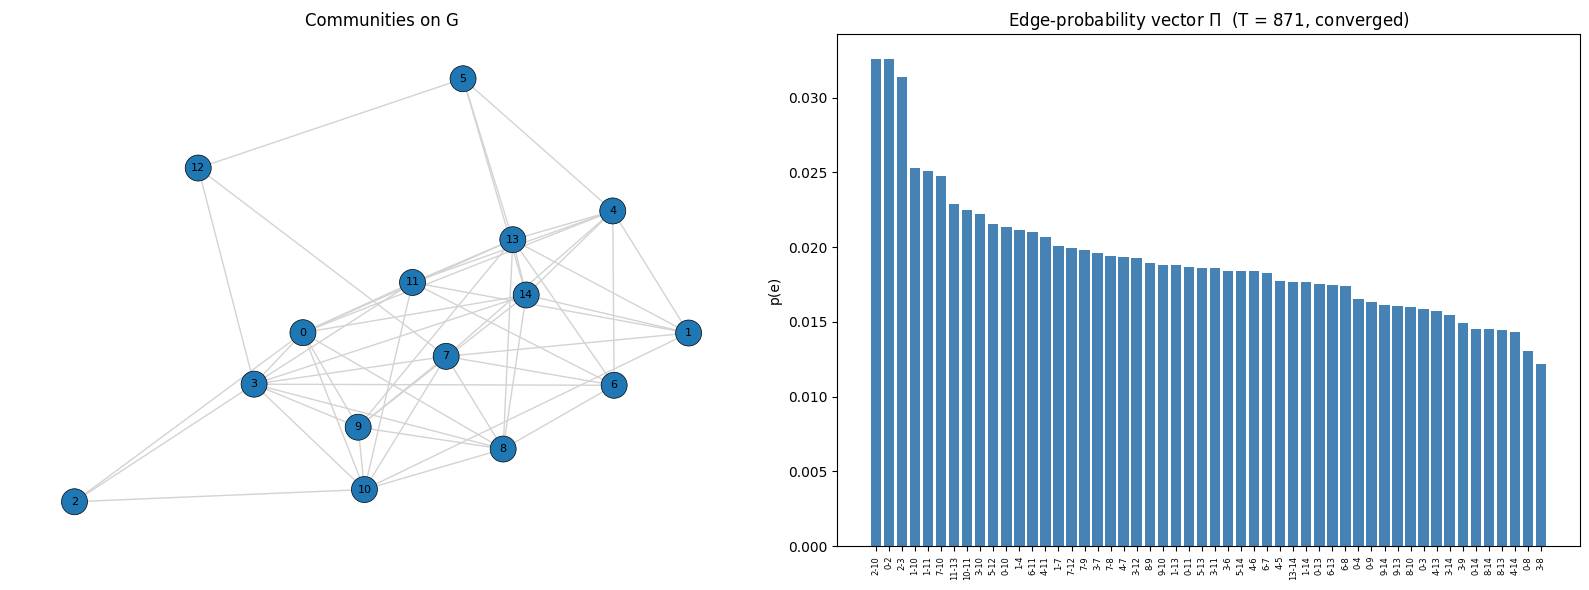

In [14]:
from quantum_walk.community_detection_qw import visualize_communities

visualize_communities(G, result_qw)


Graph: 34 nodes, 78 edges
Default q for QW: 0.0128


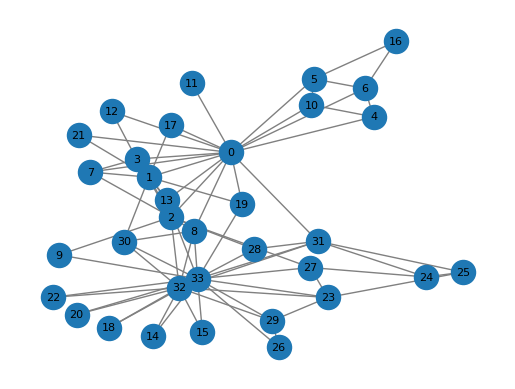

In [17]:
G = nx.karate_club_graph()
for u, v in G.edges():
    G[u][v].pop('weight', None)

k = 2  # for L-VQE: 34 qubits

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Default q for QW: {1/G.number_of_edges():.4f}")

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos=pos, node_size=300, font_size=8, edge_color="gray")
plt.axis("off")
plt.show()

In [18]:
V_max = top_k_degree_vertices(G, 2)
print(f"V_max (highest-degree nodes): {V_max}")

result_qw = detect_communities(
    G, V_max,
    q=None,         
    epsilon=1e-4,
    max_steps=2000,
    min_steps=50,
    refine=True,
    verbose=False
)

qw_communities = result_qw['communities']
qw_modularity = modularity(G, qw_communities)


print(f"QW converged: {result_qw['converged']} in {result_qw['steps_run']} steps")
print(f"QW communities found: {len(qw_communities)}")
for rep, members in qw_communities.items():
    print(f"  community {rep}: {members}")
print(f"QW modularity: {qw_modularity:.4f}")

V_max (highest-degree nodes): [33, 0]
QW converged: True in 759 steps
QW communities found: 3
  community 33: [14, 15, 18, 2, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 8, 9]
  community 0: [0, 1, 10, 12, 13, 16, 17, 19, 21, 3, 4, 5, 6, 7]
  community 11: [11]
QW modularity: 0.3525


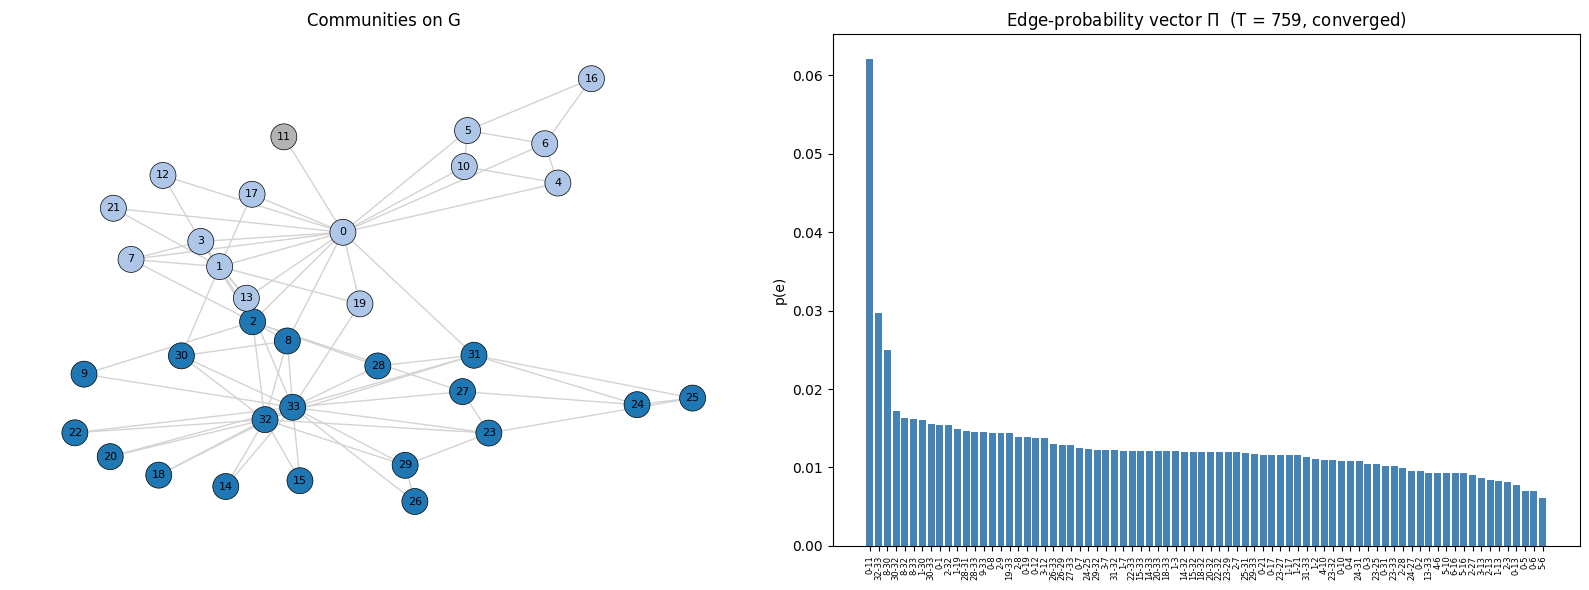

In [20]:
visualize_communities(G, result_qw)

In [21]:
k = 2
problem = CommunityDetection(G, k)

sim = QuimbSimulator()
lvqe = LayerVQE(problem=problem, simulator=sim, optimizer_class=COBYLA, n_layers=2,
    k_per_layer=200, k_final=200, use_sampling=False)

result_lvqe = lvqe.run()

Starting L-VQE: 2 layers, 200 iter/layer, 200 final iter
Mode: exact expectation

Layer 0: 



COBYLA: 100%|██████████| 200/200 [01:52<00:00,  1.77it/s, best_E=-0.3267]


Total evaluations: 200
layer 0: energy=-0.3267, approx_ratio=+0.7781

Layer 1 — 200 iterations (before convergence)


COBYLA: 100%|██████████| 200/200 [02:17<00:00,  1.46it/s, best_E=-0.3522]


Total evaluations: 200
layer 1: energy=-0.3522, approx_ratio=+0.8389

Final layer — 200 iterations (final)


COBYLA:   0%|          | 1/200 [00:00<02:46,  1.20it/s, best_E=-0.3522]/home/joaomartins_06/Layer-Variational-Quantum-Eigensolver/venv/lib/python3.12/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 300
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')
COBYLA: 300it [03:33,  1.41it/s, best_E=-0.3528]                         

Total evaluations: 300
layer 2: energy=-0.3528, approx_ratio=+0.8404


In [22]:
from itertools import product

def to_communities(assignment):
    groups = {}
    for node, label in enumerate(assignment):
        groups.setdefault(label, []).append(node)
    return groups

# L-VQE decoded
bitstrings = sim.get_most_frequent_assignments(
    result_lvqe['final_params'], result_lvqe['final_ansatz'], problem=problem
)

best_assignment, best_proba = bitstrings[0]
modularity_lvqe = problem.evaluate(best_assignment)
communities_lvqe = to_communities(best_assignment)
q_best = -problem.best_known_value  

print("LVQE decoded communities (most probable sample):")
for label, nodes in sorted(communities_lvqe.items()):
    print(f"  Community {label}: {nodes}")
print(f"LVQE decoded modularity Q = {modularity_lvqe:.4f} (probability: {best_proba:.3f}%)")
print(f"LVQE final energy (expectation) = {result_lvqe['final_energy']:.4f}")
print(f"Best-known modularity Q*        = {q_best:.4f}")
print(f"Approximation ratio (energy)    = {result_lvqe['final_approx_ratio']:.4f}")
print(f"Approximation ratio (decoded)   = {modularity_lvqe / q_best:.4f}")

LVQE decoded communities (most probable sample):
  Community 0: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
  Community 1: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
LVQE decoded modularity Q = 0.3715 (probability: 59.250%)
LVQE final energy (expectation) = -0.3528
Best-known modularity Q*        = 0.4198
Approximation ratio (energy)    = 0.8404
Approximation ratio (decoded)   = 0.8849


/tmp/ipykernel_9408/3696706647.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max(n_colors, 2))


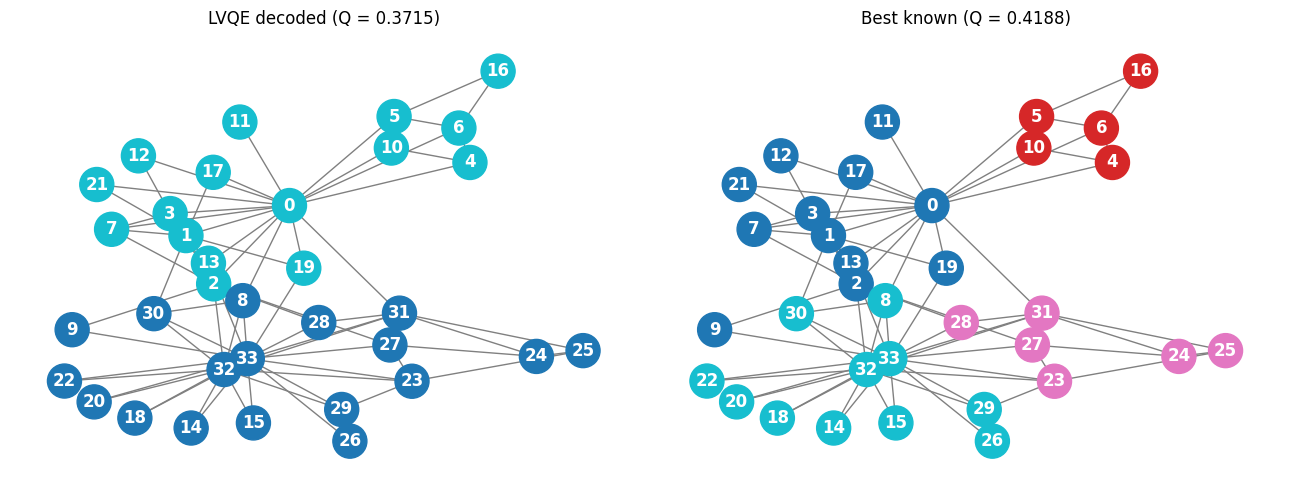

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from networkx.algorithms.community import louvain_communities

# recover the best-known assignment (Louvain, same as the class used for n>12)
best_assignment_exact = [0] * problem.num_nodes
for comm_idx, comm in enumerate(louvain_communities(G, seed=problem.seed)):
    for node in comm:
        best_assignment_exact[node] = comm_idx
best_q = problem.evaluate(best_assignment_exact)


def draw_partition(ax, assignment, title):
    pos = nx.spring_layout(G, seed=42)
    n_colors = max(assignment) + 1
    cmap = cm.get_cmap("tab10", max(n_colors, 2))
    node_colors = [cmap(assignment[node]) for node in G.nodes()]
    nx.draw_networkx(
        G, pos=pos, node_color=node_colors, with_labels=True,
        node_size=600, font_color="white", font_weight="bold",
        edge_color="gray", ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_partition(axes[0], best_assignment, f"LVQE decoded (Q = {modularity_lvqe:.4f})")
draw_partition(axes[1], best_assignment_exact, f"Best known (Q = {best_q:.4f})")
plt.tight_layout()
plt.show()